# Classification using Random Forest

## Setup

In [1]:

import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score


In [2]:

import sys

PROJECT_ROOT = Path().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import load_config

config = load_config()
PROCESSED_DATA_PATH = PROJECT_ROOT / config["data"]["processed_path"]
PROCESSED_DATA_PATH


PosixPath('/Users/janmeet/Desktop/Projects/bank-marketing copy/data/processed/bank_marketing_preprocessed.csv')

## Load Data

In [3]:

from src.data import load_processed

df = load_processed(config["data"]["processed_path"])
target_col = "y"
y = df[target_col]
X = df.drop(columns=[target_col])
feature_names = X.columns


## Train / Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Train Random Forest

In [5]:

from src.train import train_random_forest

clf = train_random_forest(X_train, y_train, config["random_forest"])


## 5-Fold Cross Validation

In [6]:
cross_val_acc = cross_val_score(clf, X_train, y_train, cv=5, scoring="accuracy")
cross_val_f1 = cross_val_score(clf, X_train, y_train, cv=5, scoring="f1")
print("5-Fold CV Accuracy:", cross_val_acc)
print("Mean CV Accuracy:", cross_val_acc.mean())
print("5-Fold CV F1 Scores:", cross_val_f1)
print("Mean CV F1:", cross_val_f1.mean())

5-Fold CV Accuracy: [0.90060698 0.90030349 0.89954476 0.89984825 0.89787557]
Mean CV Accuracy: 0.8996358118361154
5-Fold CV F1 Scores: [0.34955313 0.36027264 0.3458498  0.35166994 0.35101254]
Mean CV F1: 0.3516716092902759


## Test Set Evaluation

In [7]:

from src.evaluate import compute_metrics

y_train_pred = clf.predict(X_train)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]
metrics = compute_metrics(y_test, y_pred, y_proba)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
for name, value in metrics.items():
    print(f"{name.capitalize()}:", value)


Training Accuracy: 0.9143854324734446
Accuracy: 0.9021607186210245
Precision: 0.6732954545454546
Recall: 0.25538793103448276
F1: 0.3703125
Auc: 0.8110209355394121


## Confusion Matrix

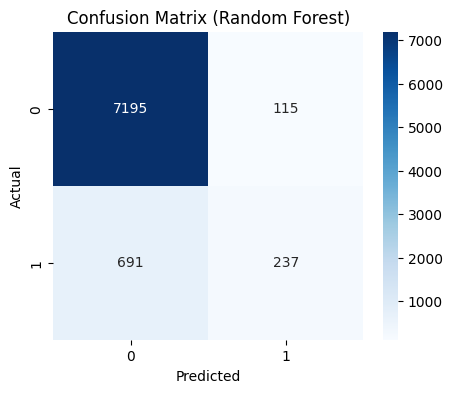

In [8]:

from src.evaluate import plot_confusion_matrix

plt.figure(figsize=(5, 4))
plot_confusion_matrix(y_test, y_pred, title="Confusion Matrix (Random Forest)")
plt.show()


## ROC Curve

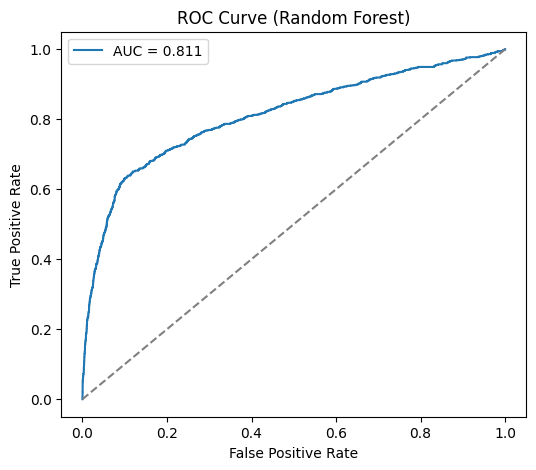

In [9]:

from src.evaluate import plot_roc_curve

plt.figure(figsize=(6, 5))
plot_roc_curve(y_test, y_proba, title="ROC Curve (Random Forest)")
plt.show()


## Baseline Classification Analysis

- The baseline Random Forest shows high accuracy, but the class imbalance causes the model to ignore some positive cases.
- Recall and F1 score are low, confirming poor minority-class performance.
- The confusion matrix clearly illustrates the majority-class dominance.
- The model provides a strong baseline for comparison, but needs augmentation techniques such as SMOTE and possibly feature selection to improve performance on minority samples.

# Data Augmentation using SMOTE

In [10]:

from src.train import apply_smote

X_smote, y_smote = apply_smote(X_train, y_train, config["smote"]["random_state"])
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_smote.value_counts())


Before SMOTE: y
0    29238
1     3712
Name: count, dtype: int64
After SMOTE: y
0    29238
1    29238
Name: count, dtype: int64


In [11]:

clf_smote = train_random_forest(X_smote, y_smote, config["random_forest"])


In [12]:

y_train_pred_smote = clf_smote.predict(X_smote)
y_pred_smote = clf_smote.predict(X_test)
y_prob_smote = clf_smote.predict_proba(X_test)[:, 1]
metrics_smote = compute_metrics(y_test, y_pred_smote, y_prob_smote)

print("Training Accuracy:", accuracy_score(y_smote, y_train_pred_smote))
for name, value in metrics_smote.items():
    print(f"{name.capitalize()}:", value)


Training Accuracy: 0.9205486011355086
Accuracy: 0.8863801893663511
Precision: 0.4962335216572505
Recall: 0.5678879310344828
F1: 0.5296482412060302
Auc: 0.8092063599698099


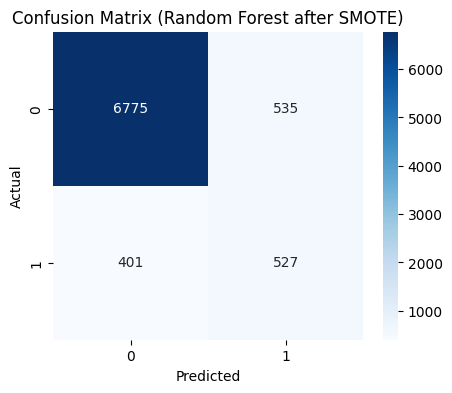

In [13]:

plt.figure(figsize=(5, 4))
plot_confusion_matrix(y_test, y_pred_smote, title="Confusion Matrix (Random Forest after SMOTE)")
plt.show()


## Classification after SMOTE Analysis

- Recall increased from 0.255 to 0.568, showing model now correctly identifies more minority class samples.
- F1-score improves significantly (0.37 to 0.53), showing much better balance between precision and recall.


# Feature Selection using L1 Logistic Regression 

In [14]:

from src.features import select_features_l1

feature_mask, lasso_logreg = select_features_l1(
    X_train, y_train, config["feature_selection"]["C"], config["feature_selection"]["random_state"]
)


In [15]:

selected_features = feature_names[feature_mask]

print("Total features:", len(feature_names))
print("Selected by Lasso:", feature_mask.sum())
print("Reduction:", len(feature_names) - feature_mask.sum())
print(selected_features)


Total features: 56
Selected by Lasso: 32
Reduction: 24
Index(['num__age', 'num__campaign', 'num__pdays', 'num__previous',
       'num__emp.var.rate', 'num__cons.price.idx', 'num__cons.conf.idx',
       'cat__job_blue-collar', 'cat__job_retired', 'cat__job_services',
       'cat__job_student', 'cat__marital_divorced', 'cat__marital_married',
       'cat__education_basic.4y', 'cat__education_basic.9y',
       'cat__education_university.degree', 'cat__default_no',
       'cat__housing_yes', 'cat__loan_no', 'cat__contact_telephone',
       'cat__month_apr', 'cat__month_aug', 'cat__month_dec', 'cat__month_jul',
       'cat__month_jun', 'cat__month_mar', 'cat__month_may', 'cat__month_nov',
       'cat__day_of_week_fri', 'cat__day_of_week_mon', 'cat__day_of_week_wed',
       'cat__poutcome_failure'],
      dtype='object')


In [16]:

X_train_lasso = X_train.loc[:, feature_mask]
X_test_lasso = X_test.loc[:, feature_mask]

X_train_lasso.shape, X_test_lasso.shape


((32950, 32), (8238, 32))

In [17]:

clf_fs = train_random_forest(X_train_lasso, y_train, config["random_forest"])


In [18]:

y_train_pred_fs = clf_fs.predict(X_train_lasso)
y_pred_fs = clf_fs.predict(X_test_lasso)
y_prob_fs = clf_fs.predict_proba(X_test_lasso)[:, 1]
metrics_fs = compute_metrics(y_test, y_pred_fs, y_prob_fs)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred_fs))
for name, value in metrics_fs.items():
    print(f"{name.capitalize()}:", value)


Training Accuracy: 0.9128983308042489
Accuracy: 0.9027676620538966
Precision: 0.6884272997032641
Recall: 0.25
F1: 0.366798418972332
Auc: 0.8072793822821831


## Feature Selection + SMOTE

In [19]:

X_lasso_smote, y_lasso_smote = apply_smote(X_train_lasso, y_train, config["smote"]["random_state"])
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_lasso_smote.value_counts())


Before SMOTE: y
0    29238
1     3712
Name: count, dtype: int64
After SMOTE: y
0    29238
1    29238
Name: count, dtype: int64


In [20]:

clf_lasso_smote = train_random_forest(X_lasso_smote, y_lasso_smote, config["random_forest"])


In [21]:

y_train_pred_lasso_smote = clf_lasso_smote.predict(X_lasso_smote)
y_pred_lasso_smote = clf_lasso_smote.predict(X_test_lasso)
y_prob_lasso_smote = clf_lasso_smote.predict_proba(X_test_lasso)[:, 1]
metrics_lasso_smote = compute_metrics(y_test, y_pred_lasso_smote, y_prob_lasso_smote)

print("Training Accuracy:", accuracy_score(y_smote, y_train_pred_lasso_smote))
for name, value in metrics_lasso_smote.items():
    print(f"{name.capitalize()}:", value)


Training Accuracy: 0.9023017990286614
Accuracy: 0.8835882495751396
Precision: 0.4857928505957837
Recall: 0.5711206896551724
F1: 0.5250123823675087
Auc: 0.8017370365347422


## Feature Selection Analysis

We apply feature selection to reduce the number of predictors and produce a smaller feature set containing only variables with the strongest linear contribution to predicting the target. 
The selected features represent high impact attributes that are important because they directly influence a customer's likelihood of responding to a marketing campaign. It helps simplify the model by eliminating redundant or weak predictors.
We didn't see much impact on the classification using Random Forest. Random Forest is a linear model that benefits from diverse features, so applying feature selection does not provide a major benefit.

Without feature selection:
- Training Accuracy: 0.9143854324734446
- Test Accuracy: 0.9021607186210245
- Precision: 0.6732954545454546
- Recall: 0.25538793103448276
- F1-Score: 0.3703125
- AUC-ROC: 0.8110209355394121

After feature selection:
- Training Accuracy: 0.9128983308042489
- Test Accuracy: 0.9027676620538966
- Precision: 0.6884272997032641
- Recall: 0.25
- F1-Score: 0.366798418972332
- AUC-ROC: 0.8072793822821831

After applyting SMOTE:
- Training Accuracy: 0.9205486011355086
- Test Accuracy: 0.8863801893663511
- Precision: 0.4962335216572505
- Recall: 0.5678879310344828
- F1-Score: 0.5296482412060302
- AUC-ROC: 0.8092063599698099

After applyting SMOTE and Feature selection:
- Training Accuracy: 0.9023017990286614
- Test Accuracy: 0.8835882495751396
- Precision: 0.4857928505957837
- Recall: 0.5711206896551724
- F1-Score: 0.5250123823675087
- AUC-ROC: 0.8017370365347422

Feature selection improves computation efficiency as it reduces the training time and produces a more compact model.

## Hyperparameter Tuning

In [22]:

from src.train import run_hyperparameter_search

search = run_hyperparameter_search(X_lasso_smote, y_lasso_smote, config["hyperparameter_search"])
best_rf = search.best_estimator_
print("Best params:", search.best_params_)


Best params: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}


In [23]:

best_metrics = compute_metrics(
    y_test, best_rf.predict(X_test_lasso), best_rf.predict_proba(X_test_lasso)[:, 1]
)
for name, value in best_metrics.items():
    print(f"{name.capitalize()}:", value)


Accuracy: 0.8851663025006069
Precision: 0.48732394366197185
Recall: 0.3728448275862069
F1: 0.42246642246642246
Auc: 0.7868090770791075


Hyperparameter tuning using RandomizedSearchCV did not improve the model’s performance compared to the untuned model trained on SMOTE-balanced data.

The tuning was performed after feature selection, which reduced the feature space significantly. Random Forests generally perform better with a larger number of features, especially for datasets with many one-hot encoded categorical variables, as they rely on feature interactions to form complex decision rules.

Overall, the default Random Forest applied on SMOTE-balanced data produced the best results.